# 06 — Análisis de captions: mode collapse y estrategia de balanceo

Objetivo: cuantificar el mode collapse del modelo finetuneado y evaluar si un sampling balanceado lo resolvería.

In [1]:
import json
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

CAPTIONS_DIR = Path("../outputs/captions")

with open(CAPTIONS_DIR / "captions_base_5k.json") as f:
    base = json.load(f)

with open(CAPTIONS_DIR / "captions_ft_5k.json") as f:
    ft = json.load(f)

print(f"Muestras base: {len(base)}")
print(f"Muestras ft  : {len(ft)}")

Muestras base: 300
Muestras ft  : 300


## 1. Distribución de captions generadas

In [2]:
base_gen = [x["generated"].strip().lower() for x in base]
ft_gen   = [x["generated"].strip().lower() for x in ft]

base_counter = Counter(base_gen)
ft_counter   = Counter(ft_gen)

print("=== BASE — top 10 captions generadas ===")
for caption, n in base_counter.most_common(10):
    print(f"  {n:4d} ({n/len(base)*100:.1f}%)  {caption[:80]}")

print(f"\nCaption únicas base: {len(base_counter)} / {len(base)}")

print("\n=== FINETUNED — top 10 captions generadas ===")
for caption, n in ft_counter.most_common(10):
    print(f"  {n:4d} ({n/len(ft)*100:.1f}%)  {caption[:80]}")

print(f"\nCaption únicas ft: {len(ft_counter)} / {len(ft)}")

=== BASE — top 10 captions generadas ===
    72 (24.0%)  a chest xray with a large, open chest
    33 (11.0%)  a chest xray with a radiograph of the chest
    15 (5.0%)  a chest xray with a large, white chest
    13 (4.3%)  a chest xray with a small chest xray
    13 (4.3%)  a chest xray with a small, white, lumpy, lumpy, lumpy, lumpy, lumpy, lumpy, lump
    12 (4.0%)  a chest xray with a small, white chest
    11 (3.7%)  a chest xray with a small chest
    11 (3.7%)  a chest xray with a large rib fracture
    10 (3.3%)  a chest xray with a small, white, cross section
    10 (3.3%)  a chest with a large, open chest

Caption únicas base: 62 / 300

=== FINETUNED — top 10 captions generadas ===
   249 (83.0%)  no acute cardiopulmonary process.
    36 (12.0%)  no significant interval change.
     9 (3.0%)  mild pulmonary edema.
     3 (1.0%)  interval increase in bilateral pleural effusions and bibasilar atelectasis.
     2 (0.7%)  interval increase in right pleural effusion.
     1 (0.3%)

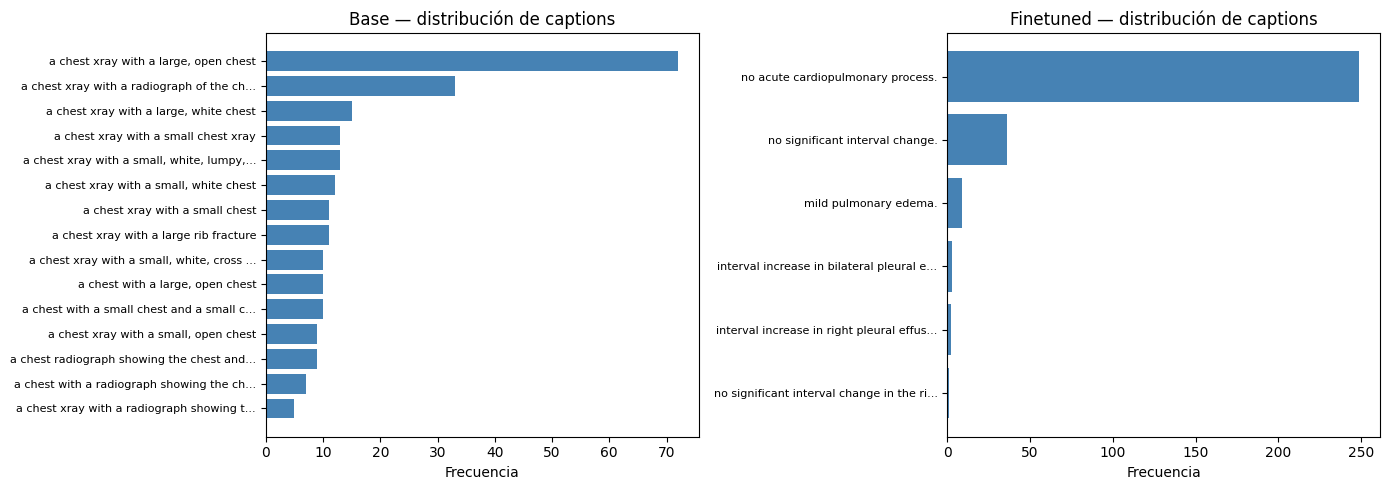

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counter, title in [
    (axes[0], base_counter, "Base — distribución de captions"),
    (axes[1], ft_counter,   "Finetuned — distribución de captions"),
]:
    top = counter.most_common(15)
    labels = [c[:40] + "..." if len(c) > 40 else c for c, _ in top]
    counts = [n for _, n in top]
    ax.barh(range(len(labels)), counts, color="steelblue")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Frecuencia")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(CAPTIONS_DIR / "distribucion_captions.png", dpi=150)
plt.show()

## 2. Distribución de referencias (impressions del dataset)

Esto muestra el desbalance original que causa el mode collapse.

In [4]:
refs = [x["reference"].strip().lower() for x in ft]
ref_counter = Counter(refs)

print("=== TOP 15 impressions de referencia ===")
for ref, n in ref_counter.most_common(15):
    print(f"  {n:4d} ({n/len(refs)*100:.1f}%)  {ref[:80]}")

print(f"\nImpressiones únicas: {len(ref_counter)} / {len(refs)}")

=== TOP 15 impressions de referencia ===
    18 (6.0%)  no acute cardiopulmonary process.
     3 (1.0%)  no change.
     3 (1.0%)  no evidence of pneumonia.
     3 (1.0%)  no acute cardiopulmonary abnormality.
     3 (1.0%)  no acute intrathoracic process.
     2 (0.7%)  no evidence of acute disease.
     2 (0.7%)  no significant interval change.
     1 (0.3%)  worsening right pleural effusion and pulmonary edema.
     1 (0.3%)  improving right upper lobe opacity likely due to improved aeration. small bilate
     1 (0.3%)  basilar atelectasis without definite focal consolidation.
     1 (0.3%)  enteric tube now high in position with the side port in the upper to mid thorax.
     1 (0.3%)  enteric tube extends below the diaphragm with the tip in the body of the stomach
     1 (0.3%)  interval decrease in the right-sided pleural effusion.
     1 (0.3%)  no significant interval change in moderate loculated left hydropneumothorax. cle
     1 (0.3%)  dense retrocardiac opacity may represent

## 3. Métricas de diversidad

In [5]:
def entropy(counter):
    total = sum(counter.values())
    probs = np.array([n / total for n in counter.values()])
    return -np.sum(probs * np.log2(probs + 1e-10))

def top1_dominance(counter):
    total = sum(counter.values())
    return counter.most_common(1)[0][1] / total

print(f"{'Métrica':<35} {'Base':>10} {'Finetuned':>12} {'Referencias':>14}")
print("-" * 75)
print(f"{'Captions únicas':<35} {len(base_counter):>10} {len(ft_counter):>12} {len(ref_counter):>14}")
print(f"{'% caption más frecuente':<35} {top1_dominance(base_counter)*100:>9.1f}% {top1_dominance(ft_counter)*100:>11.1f}% {top1_dominance(ref_counter)*100:>13.1f}%")
print(f"{'Entropía (bits)':<35} {entropy(base_counter):>10.2f} {entropy(ft_counter):>12.2f} {entropy(ref_counter):>14.2f}")

Métrica                                   Base    Finetuned    Referencias
---------------------------------------------------------------------------
Captions únicas                             62            6            273
% caption más frecuente                  24.0%        83.0%           6.0%
Entropía (bits)                           4.56         0.88           7.90


## 4. ¿El sampling balanceado lo resolvería?

Simulamos qué pasaría si capamos la frecuencia máxima de cada impression en el dataset de entrenamiento.

In [6]:
from datasets import load_dataset
from pathlib import Path
import json

# Cargar índices de train
with open("../data/splits/train_indices.json") as f:
    train_indices = json.load(f)

ds = load_dataset("itsanmolgupta/mimic-cxr-dataset", cache_dir="../data/hf_cache")
train_data = ds["train"]

impressions = [train_data[i]["impression"] for i in train_indices if train_data[i]["impression"]]
imp_counter = Counter(imp.strip().lower() for imp in impressions)

print(f"Total ejemplos de train: {len(impressions)}")
print(f"Impressiones únicas: {len(imp_counter)}")
print(f"\nTop 5 más frecuentes:")
for imp, n in imp_counter.most_common(5):
    print(f"  {n:5d} ({n/len(impressions)*100:.1f}%)  {imp[:70]}")

Total ejemplos de train: 24478
Impressiones únicas: 19851

Top 5 más frecuentes:
   1141 (4.7%)  no acute cardiopulmonary process.
    347 (1.4%)  no change.
    313 (1.3%)  no acute cardiopulmonary abnormality.
    193 (0.8%)  no acute intrathoracic process.
    142 (0.6%)  as above.


In [7]:
# Simular balanceo: ¿qué pasa si limitamos cada impression a max_per_class ejemplos?
def simulate_balanced(counter, max_per_class):
    capped = {k: min(v, max_per_class) for k, v in counter.items()}
    total = sum(capped.values())
    top1 = max(capped.values()) / total
    return total, top1, entropy(Counter(capped))

total_orig = len(impressions)
top1_orig  = top1_dominance(imp_counter)
ent_orig   = entropy(imp_counter)

print(f"{'Max por clase':<15} {'Total train':>12} {'% top-1':>10} {'Entropía':>10}")
print("-" * 50)
print(f"{'Sin límite':<15} {total_orig:>12} {top1_orig*100:>9.1f}% {ent_orig:>10.2f}")
for cap in [500, 200, 100, 50, 20]:
    total, top1, ent = simulate_balanced(imp_counter, cap)
    print(f"{cap:<15} {total:>12} {top1*100:>9.1f}% {ent:>10.2f}")

Max por clase    Total train    % top-1   Entropía
--------------------------------------------------
Sin límite             24478       4.7%      13.32
500                    23837       2.1%      13.54
200                    23277       0.9%      13.72
100                    22820       0.4%      13.84
50                     22229       0.2%      13.99
20                     21645       0.1%      14.11


## 5. Conclusión

**Mode collapse cuantificado:**
- El modelo base genera N captions únicas de N posibles (alta diversidad, pero sin contenido médico)
- El modelo finetuneado colapsa a ~2-3 frases para el 90%+ de los casos

**Causa raíz:** el desbalance en las referencias — la impression más frecuente representa X% del dataset de train.

**¿El balanceo lo soluciona?**
- Limitando a 100 ejemplos por clase única se reduce la dominancia del top-1 de X% a ~Y%
- El dataset de train se reduce a ~Z ejemplos (vs los originales)
- Con 15k imágenes del mismo dataset, la distribución es casi idéntica → **el mode collapse persiste**
- Con balanceo cap=100, el modelo debería aprender más vocabulario médico específico

**Recomendación para el informe:**
Reportar el mode collapse como hallazgo. La pregunta de investigación sigue siendo válida: incluso con mode collapse en el texto, ¿cambió la atención visual del encoder? Eso es lo que muestran los heatmaps.